In [ ]:
# Montar Google Drive y cargar el CSV usando encoding='latin1'
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

# 1. Cargar el archivo con la codificación correcta
df = pd.read_csv('/content/drive/MyDrive/semestre 6/sist int/ensayos_imu.csv', encoding='latin1')

# 2. Corregir cualquier variación en la etiqueta 'atrás'
df['Direccion'] = df['Direccion'].replace({'atrï¿½s': 'atrás', 'atr\ufffds': 'atrás'})

# 3. Mostrar las direcciones únicas encontradas y las primeras filas
print("Direcciones encontradas en el archivo:", df['Direccion'].unique())
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Direcciones encontradas en el archivo: ['adelante' 'atrás' 'derecha' 'izquierda' 'N']


,user_id,trial_id,sample_id,a_x,a_y,a_z,w_x,w_y,w_z,m_x,m_y,m_z,Direccion,velocidad_objetivo
0,0,1,1,-9.52284,-0.57846,-0.53839,4.34000,-1.75875,-4.44500,-104.4,2.4,-204.45,adelante,1.0
1,0,1,2,-9.48455,-0.62154,-0.46481,2.77375,-1.69750,-3.31625,-104.4,2.4,-204.45,adelante,1.0
2,0,1,3,-9.41755,-0.57188,-0.48754,2.57250,-2.94875,-3.76250,-104.4,2.4,-204.45,adelante,1.0
3,0,1,4,-9.45584,-0.60000,-0.47617,3.78000,-3.55250,-4.09500,-104.4,2.4,-204.45,adelante,1.0
4,0,1,5,-9.41636,-0.68315,-0.54257,3.63125,-4.46250,-3.57875,-104.4,2.4,-204.45,adelante,1.0


In [ ]:
# 1. Normalizar codificación de caracteres para la etiqueta 'atrás'
df['Direccion'] = df['Direccion'].replace({'atrï¿½s': 'atrás'})

# 2. Definir las 5 clases objetivo y filtrar el dataframe
direcciones_objetivo = ['adelante', 'atrás', 'izquierda', 'derecha', 'N']
df_modelo = df[df['Direccion'].isin(direcciones_objetivo)].copy()

# 3. Verificar el balance de las 5 clases
print("Tamaño total del dataset para entrenamiento:", df_modelo.shape)
print("\nMuestras registradas por dirección:")
print(df_modelo['Direccion'].value_counts())

Tamaño total del dataset para entrenamiento: (27423, 14)

Muestras registradas por dirección:
Direccion
adelante     6968
atrás        6131
izquierda    5294
derecha      4826
N            4204
Name: count, dtype: int64


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 0. Corrección de codificación en la columna Direccion
df_modelo['Direccion'] = df_modelo['Direccion'].replace({
    'atrï¿½s': 'atras',
    'atrás': 'atras'
})

# ==============================================================================
# INGENIERÍA DE CARACTERÍSTICAS (FEATURE ENGINEERING)
# ==============================================================================

# A. Magnitudes Vectoriales (Normas Euclidianas)
df_modelo['a_mag'] = np.sqrt(df_modelo['a_x']**2 + df_modelo['a_y']**2 + df_modelo['a_z']**2)
df_modelo['w_mag'] = np.sqrt(df_modelo['w_x']**2 + df_modelo['w_y']**2 + df_modelo['w_z']**2)
df_modelo['m_mag'] = np.sqrt(df_modelo['m_x']**2 + df_modelo['m_y']**2 + df_modelo['m_z']**2)

# B. Ángulos de Inclinación (Roll y Pitch a partir del Acelerómetro)
df_modelo['roll_acc'] = np.arctan2(df_modelo['a_y'], df_modelo['a_z'])
df_modelo['pitch_acc'] = np.arctan2(-df_modelo['a_x'], np.sqrt(df_modelo['a_y']**2 + df_modelo['a_z']**2))

# C. Ángulos de Inclinación derivados del Magnetómetro
df_modelo['roll_mag'] = np.arctan2(df_modelo['m_y'], df_modelo['m_z'])
df_modelo['pitch_mag'] = np.arctan2(-df_modelo['m_x'], np.sqrt(df_modelo['m_y']**2 + df_modelo['m_z']**2))

# D. Interacciones/Productos entre ejes de Aceleración (para capturar diagonalidad)
df_modelo['ax_ay'] = df_modelo['a_x'] * df_modelo['a_y']
df_modelo['ax_az'] = df_modelo['a_x'] * df_modelo['a_z']
df_modelo['ay_az'] = df_modelo['a_y'] * df_modelo['a_z']

# ==============================================================================
# PREPARACIÓN Y SPLIT DE DATOS
# ==============================================================================

# 1. Definir la lista ampliada de características de entrada
feature_cols = [
    # Datos crudos de la IMU (9 DOF)
    'a_x', 'a_y', 'a_z',
    'w_x', 'w_y', 'w_z',
    'm_x', 'm_y', 'm_z',
    # Magnitudes
    'a_mag', 'w_mag', 'm_mag',
    # Ángulos de inclinación
    'roll_acc', 'pitch_acc',
    'roll_mag', 'pitch_mag',
    # Interacciones entre ejes
    'ax_ay', 'ax_az', 'ay_az'
]

X = df_modelo[feature_cols].values
y_raw = df_modelo['Direccion'].values

# 2. Codificar etiquetas categóricas
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

# 3. División estratificada Train (80%) y Test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 4. Normalización Z-score (Estandarización)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Número de características de entrada: {X.shape[1]}")
print(f"Tamaño del conjunto de Train: {X_train_scaled.shape[0]} muestras ({X_train_scaled.shape[0]/len(X)*100:.1f}%)")
print(f"Tamaño del conjunto de Test : {X_test_scaled.shape[0]} muestras ({X_test_scaled.shape[0]/len(X)*100:.1f}%)")
print("\nClases codificadas:", dict(zip(label_encoder.classes_, range(len(label_encoder.classes_)))))

Número de características de entrada: 19
Tamaño del conjunto de Train: 21938 muestras (80.0%)
Tamaño del conjunto de Test : 5485 muestras (20.0%)

Clases codificadas: {'N': 0, 'adelante': 1, 'atras': 2, 'derecha': 3, 'izquierda': 4}


In [ ]:
# ==============================================================================
# EXPORTACIÓN DE PARÁMETROS PARA ESP32 (SOFTMAX + SCALER)
# ==============================================================================

import numpy as np

# Extraer parámetros del modelo entrenado
W = model_win.coef_          # Forma: [NUM_CLASSES, NUM_FEATURES]
b = model_win.intercept_     # Forma: [NUM_CLASSES]
mean = scaler_w.mean_        # Forma: [NUM_FEATURES]
scale = scaler_w.scale_      # Forma: [NUM_FEATURES]
clases = label_encoder_win.classes_

n_clases, n_features = W.shape

print("// ==============================================================================")
print("// ARCHIVO DE CONFIGURACIÓN Y PESOS DEL MODELO SOFTMAX PARA ESP32")
print("// ==============================================================================\n")

print(f"const int NUM_FEATURES = {n_features};")
print(f"const int NUM_CLASSES = {n_clases};\n")

# Nombres de las clases
classes_str = ", ".join([f'"{c}"' for c in clases])
print(f"const char* CLASS_NAMES[NUM_CLASSES] = {{ {classes_str} }};\n")

# Parámetros del StandardScaler para normalizar en la ESP32
mean_str = ", ".join([f"{m:.6f}f" for m in mean])
scale_str = ", ".join([f"{s:.6f}f" for s in scale])
print(f"const float SCALER_MEAN[NUM_FEATURES] = {{ {mean_str} }};\n")
print(f"const float SCALER_SCALE[NUM_FEATURES] = {{ {scale_str} }};\n")

# Matriz de Pesos W [NUM_CLASSES][NUM_FEATURES]
print(f"const float THETA_W[{n_clases}][{n_features}] = {{")
for i, fila in enumerate(W):
    pesos_str = ", ".join([f"{w:.6f}f" for w in fila])
    comma = "," if i < n_clases - 1 else ""
    print(f"    // Clase {i}: {clases[i]}")
    print(f"    {{ {pesos_str} }}{comma}")
print("};\n")

# Vector de Sesgos / Interceptos b [NUM_CLASSES]
bias_str = ", ".join([f"{bias:.6f}f" for bias in b])
print(f"const float THETA_B[NUM_CLASSES] = {{ {bias_str} }};\n")

# Función de inferencia para ESP32
print("// ==============================================================================")
print("// FUNCIÓN DE INFERENCIA EN C++ PARA ESP32")
print("// ==============================================================================")
print("""
int predecir_direccion(float x_raw[]) {
    float x_scaled[NUM_FEATURES];

    // 1. Escalado estándar (StandardScaler)
    for (int j = 0; j < NUM_FEATURES; j++) {
        x_scaled[j] = (x_raw[j] - SCALER_MEAN[j]) / SCALER_SCALE[j];
    }

    // 2. Cálculo de Logits z_k para cada clase
    float max_z = -1e9;
    int mejor_clase = 0;

    for (int k = 0; k < NUM_CLASSES; k++) {
        float z_k = THETA_B[k];
        for (int j = 0; j < NUM_FEATURES; j++) {
            z_k += THETA_W[k][j] * x_scaled[j];
        }

        if (z_k > max_z) {
            max_z = z_k;
            mejor_clase = k;
        }
    }

    return mejor_clase; // Retorna el índice de la clase predicha
}
""")

// ==============================================================================
// ARCHIVO DE CONFIGURACIÓN Y PESOS DEL MODELO SOFTMAX PARA ESP32
// ==============================================================================

const int NUM_FEATURES = 76;
const int NUM_CLASSES = 5;

const char* CLASS_NAMES[NUM_CLASSES] = { "N", "adelante", "atras", "derecha", "izquierda" };

const float SCALER_MEAN[NUM_FEATURES] = { -8.843102f, -0.025414f, 0.421956f, 5.172899f, 2.269647f, -6.094260f, -55.872810f, -63.972409f, 10.063589f, 9.699118f, 57.044426f, 234.748204f, -0.403386f, 1.289833f, -0.936661f, 0.216854f, 0.810340f, -4.791716f, 1.673755f, 0.297028f, 0.427257f, 0.374194f, 6.893499f, 12.927133f, 13.755418f, 6.335418f, 3.576971f, 3.739085f, 0.233794f, 18.586306f, 5.116888f, 0.458050f, 0.053482f, 0.131066f, 0.025257f, 3.638327f, 3.106577f, 1.069220f, -9.346291f, -0.774264f, -0.206230f, -6.024267f, -18.181639f, -28.186434f, -64.956884f, -68.629484f, 5.021558f, 9.291558f, 29.578999f, 227.692

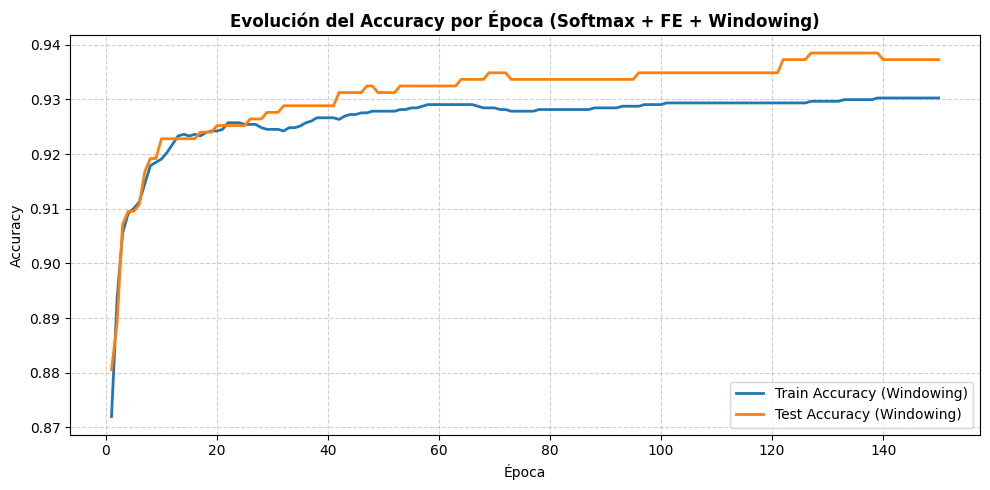

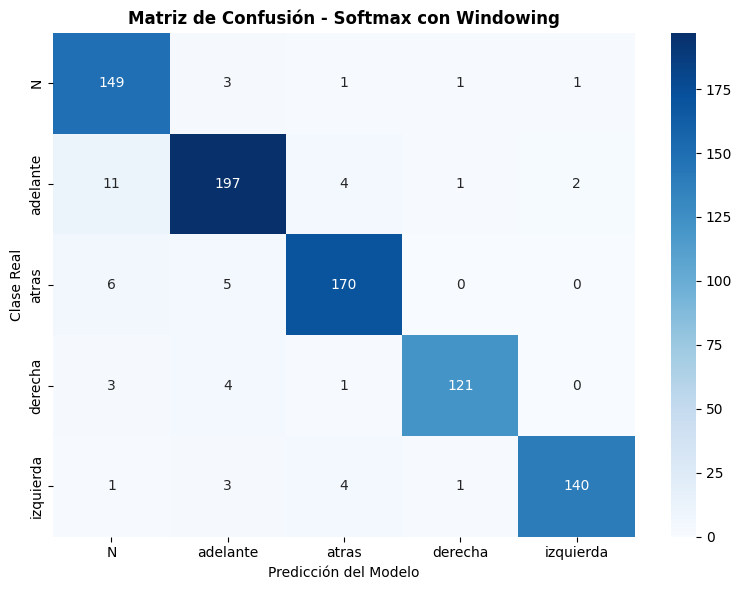

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ==============================================================================
# VISUALIZACIÓN DE LA EVOLUCIÓN DEL ACCURACY Y MATRIZ DE CONFUSIÓN
# ==============================================================================

# 1. Gráfica de la evolución del Accuracy por época
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_accs, label='Train Accuracy (Windowing)', color='#1f77b4', linewidth=2)
plt.plot(range(1, epochs + 1), test_accs, label='Test Accuracy (Windowing)', color='#ff7f0e', linewidth=2)

plt.title('Evolución del Accuracy por Época (Softmax + FE + Windowing)', fontsize=12, fontweight='bold')
plt.xlabel('Época', fontsize=10)
plt.ylabel('Accuracy', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

# 2. Matriz de Confusión en Test
y_test_pred_win = model_win.predict(X_test_w_scaled)
cm = confusion_matrix(y_test_w, y_test_pred_win)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder_win.classes_,
    yticklabels=label_encoder_win.classes_
)
plt.title('Matriz de Confusión - Softmax con Windowing', fontsize=12, fontweight='bold')
plt.xlabel('Predicción del Modelo', fontsize=10)
plt.ylabel('Clase Real', fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# --- 1. EXTRAER Y FORMATO DE PARÁMETROS PARA ESP32 ---

# Extraer pesos (theta_1, theta_2, ...) y sesgo/intercepto (theta_0)
pesos = model.coef_.flatten()
intercepto = model.intercept_[0] if isinstance(model.intercept_, (list, np.ndarray)) else model.intercept_

# Imprimir variables listas para C++ (Arduino / ESP32)
print("// ==================================================")
print("//   PARAMETROS DEL MODELO PARA ESP32 (C++)")
print("// ==================================================\n")

# Copiar como un arreglo de floats
print(f"const int NUM_FEATURES = {len(pesos)};")
print("const float THETA_PESOS[] = {")
print("    " + ", ".join([f"{w:.6f}f" for w in pesos]))
print("};")
print(f"const float THETA_INTERCEPTO = {intercepto:.6f}f;\n")


# --- 2. GENERADOR DE FUNCIÓN DE PREDICCIÓN EN C++ ---

print("// --- Copia esta función directamente en tu código de ESP32 ---")
print("""
float predecir_modelo(float x[]) {
    float z = THETA_INTERCEPTO;
    for (int i = 0; i < NUM_FEATURES; i++) {
        z += THETA_PESOS[i] * x[i];
    }

    // Si tu modelo es REGRESIÓN LINEAL, usa esto:
    return z;

    // Si tu modelo es REGRESIÓN LOGÍSTICA (Clasificación), descomenta la siguiente línea:
    // return 1.0 / (1.0 + exp(-z)); // Devuelve la probabilidad (0.0 a 1.0)
}
""")

// ==================================================
//   PARAMETROS DEL MODELO PARA ESP32 (C++)
// ==================================================

const int NUM_FEATURES = 95;
const float THETA_PESOS[] = {
    -0.623814f, -0.126710f, 0.365535f, 0.704612f, 0.663685f, 0.157819f, -0.911654f, -1.019494f, 0.422841f, -1.703165f, -5.326239f, -0.719685f, 0.214318f, 2.828474f, -0.048099f, 0.583872f, 0.231596f, -0.842117f, 0.068402f, -0.159190f, -0.359854f, 3.716962f, 0.629310f, 0.971617f, 0.278477f, -0.725458f, 0.380850f, 0.631285f, 0.919876f, -0.580932f, 0.228191f, -0.955347f, 0.874102f, -0.272752f, -0.466920f, -0.607664f, 1.072183f, -0.160638f, -1.534823f, 0.602863f, -2.505141f, -0.610648f, -1.165142f, -0.263839f, 0.856001f, 0.378779f, 0.521142f, -0.925613f, -0.150233f, -0.284580f, -0.388750f, -1.345113f, -0.383814f, 1.172025f, 0.340258f, -0.814219f, -0.342719f, -1.510628f, -3.673721f, -0.453423f, -0.745173f, 0.140930f, 1.167580f, -0.662084f, -0.365954f, -0.208511f, 0.260123f, -0.420943